In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col


# 1. Initialize a LOCAL Spark session just for Jupyter
spark = SparkSession.builder \
    .appName("View_Cleaned_Data") \
    .master("local[*]") \
    .getOrCreate()

# 2. Read the Parquet folder 
# (Jupyter maps your project folder to /home/jovyan/work)
events_clean_df = spark.read.parquet("/home/jovyan/work/cleaned/events_clean")

# 3. Apply the transformations: drop session_id and sort by user_id
events_modified_df = events_clean_df \
    .drop("session_id") \
    .orderBy(col("user_id").desc())

# 4. Print the schema to verify session_id is gone
print("--- SCHEMA ---")
events_modified_df.printSchema()

row_count = events_clean_df.count()
print(f"--- TOTAL ROWS: {row_count} ---")

# 5. Show the top 10 rows of the actual data, now sorted by user_id
print("--- TOP 10 ROWS ---")
events_modified_df.show(20, truncate=False)

--- SCHEMA ---
root
 |-- user_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: double (nullable = true)
 |-- device: string (nullable = true)
 |-- referrer: string (nullable = true)

--- TOTAL ROWS: 17996290 ---
--- TOP 10 ROWS ---
+-------+-------------------+-----------+----------+-------+-----------+
|user_id|timestamp          |event_type |product_id|device |referrer   |
+-------+-------------------+-----------+----------+-------+-----------+
|9_9    |2022-09-05 14:44:25|view       |1219.0    |desktop|organic    |
|9_9    |2023-11-12 11:18:10|click      |469.0     |mobile |social     |
|9_9    |2023-03-01 18:29:58|view       |672.0     |mobile |social     |
|9_9    |2022-01-06 15:30:54|view       |641.0     |desktop|direct     |
|9_9    |2023-02-19 12:47:36|view       |1697.0    |mobile |organic    |
|9_9    |2021-06-04 18:04:56|view       |1112.0    |mobile |organic    |
|9_9    |2022-06-09 20:14:22

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col
# 1. Initialize a LOCAL Spark session just for Jupyter
spark = SparkSession.builder \
    .appName("View_Cleaned_Data") \
    .master("local[*]") \
    .getOrCreate()

# 2. Read the Parquet folder 
# (Jupyter maps your project folder to /home/jovyan/work)
events_clean_df = spark.read.parquet("/home/jovyan/work/cleaned/events_clean")

# user_1_events = events_clean_df.filter(col("user_id") == 7).orderBy("timestamp")

# # 4. Print the total number of events for this user
# print(f"--- TOTAL EVENTS FOR USER 1: {user_1_events.count()} ---")

# # 5. Show the actual data
# print("\n--- TIMELINE FOR USER 1 ---")
# user_1_events.show(truncate=False)

row_count = events_clean_df.count()
print(f"--- TOTAL ROWS: {row_count} ---")

# # 3. Print the schema to verify our data types and our Catalog join
# print("--- SCHEMA ---")
# events_clean_df.printSchema()

# 4. Show the top 10 rows of the actual data
print("--- TOP 200 ROWS ---")
events_clean_df.show(20, truncate=False)

--- TOTAL ROWS: 17996290 ---
--- TOP 200 ROWS ---
+--------+-------------------+-----------+----------+-------+-----------+
|user_id |timestamp          |event_type |product_id|device |referrer   |
+--------+-------------------+-----------+----------+-------+-----------+
|79422_3 |2023-05-04 15:10:07|view       |757.0     |mobile |organic    |
|79422_4 |2023-05-04 15:10:07|view       |757.0     |mobile |organic    |
|79422_10|2023-05-04 15:10:07|view       |757.0     |mobile |organic    |
|59861_4 |2021-08-03 17:50:21|click      |1905.0    |desktop|organic    |
|73609_1 |2022-11-15 07:03:12|view       |97.0      |mobile |organic    |
|73609_5 |2022-11-15 07:03:12|view       |97.0      |mobile |organic    |
|73609_6 |2022-11-15 07:03:12|view       |97.0      |mobile |organic    |
|74124_10|2022-04-08 10:18:40|view       |1681.0    |NULL   |direct     |
|23016_9 |2021-04-08 02:32:57|add_to_cart|1484.0    |mobile |organic    |
|39005_7 |2021-09-22 11:10:28|click      |1235.0    |mobile |p

In [3]:
from pyspark.sql import SparkSession

# 1. Initialize a LOCAL Spark session just for Jupyter
spark = SparkSession.builder \
    .appName("View_Sessionized_Data") \
    .master("local[*]") \
    .getOrCreate()

# 2. Read the Sessionized Parquet folder
events_sessions_df = spark.read.parquet("/home/jovyan/work/output/events_with_sessions")

# 3. Print the total row count
row_count = events_sessions_df.count()
print(f"--- TOTAL ROWS: {row_count} ---")

# 4. Print the schema to verify our new session_id column
print("\n--- SCHEMA ---")
events_sessions_df.printSchema()

# 5. Show the top 20 rows, ordered chronologically per user to visually verify sessions
print("\n--- TOP 20 ROWS (Chronological by User) ---")
events_sessions_df.orderBy("user_id", "timestamp").show(200, truncate=False)

--- TOTAL ROWS: 17996290 ---

--- SCHEMA ---
root
 |-- user_id: string (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- event_type: string (nullable = true)
 |-- product_id: double (nullable = true)
 |-- device: string (nullable = true)
 |-- referrer: string (nullable = true)
 |-- session_id: string (nullable = true)


--- TOP 20 ROWS (Chronological by User) ---
+---------+-------------------+-----------+----------+-------+-----------+------------+
|user_id  |timestamp          |event_type |product_id|device |referrer   |session_id  |
+---------+-------------------+-----------+----------+-------+-----------+------------+
|100000_1 |2021-05-04 14:45:38|view       |2.0       |mobile |organic    |100000_1_1  |
|100000_1 |2021-07-18 07:08:10|view       |19.0      |desktop|organic    |100000_1_2  |
|100000_1 |2021-07-30 18:30:31|view       |1269.0    |mobile |organic    |100000_1_3  |
|100000_1 |2021-08-29 21:21:59|view       |379.0     |mobile |direct     |100000_1_4  |
|

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

# 1. Initialize local Spark session
spark = SparkSession.builder.appName("Investigate_None_Category").master("local[*]").getOrCreate()

# 2. Load the base sessionized events and the catalog
events_df = spark.read.parquet("/home/jovyan/work/output/events_with_sessions")
catalog_df = spark.read.parquet("/home/jovyan/work/cleaned/catalog_clean")

# 3. Re-create the Left Join (this is where the "none"/nulls are born!)
events_enriched = events_df.join(catalog_df, on="product_id", how="left")

# 4. Filter for rows where category is null or literally the string "none"
missing_categories = events_enriched.filter(
    col("category").isNull() | (col("category") == "none")
)

print("--- RAW EVENTS MISSING A CATEGORY ---")
# 5. Select only the columns you care about to keep the output clean
missing_categories.select(
    "user_id", 
    "session_id", 
    "event_type", 
    "product_id", 
    "category"
).show(20, truncate=False)

--- RAW EVENTS MISSING A CATEGORY ---
+-------+----------+----------+----------+--------+
|user_id|session_id|event_type|product_id|category|
+-------+----------+----------+----------+--------+
+-------+----------+----------+----------+--------+



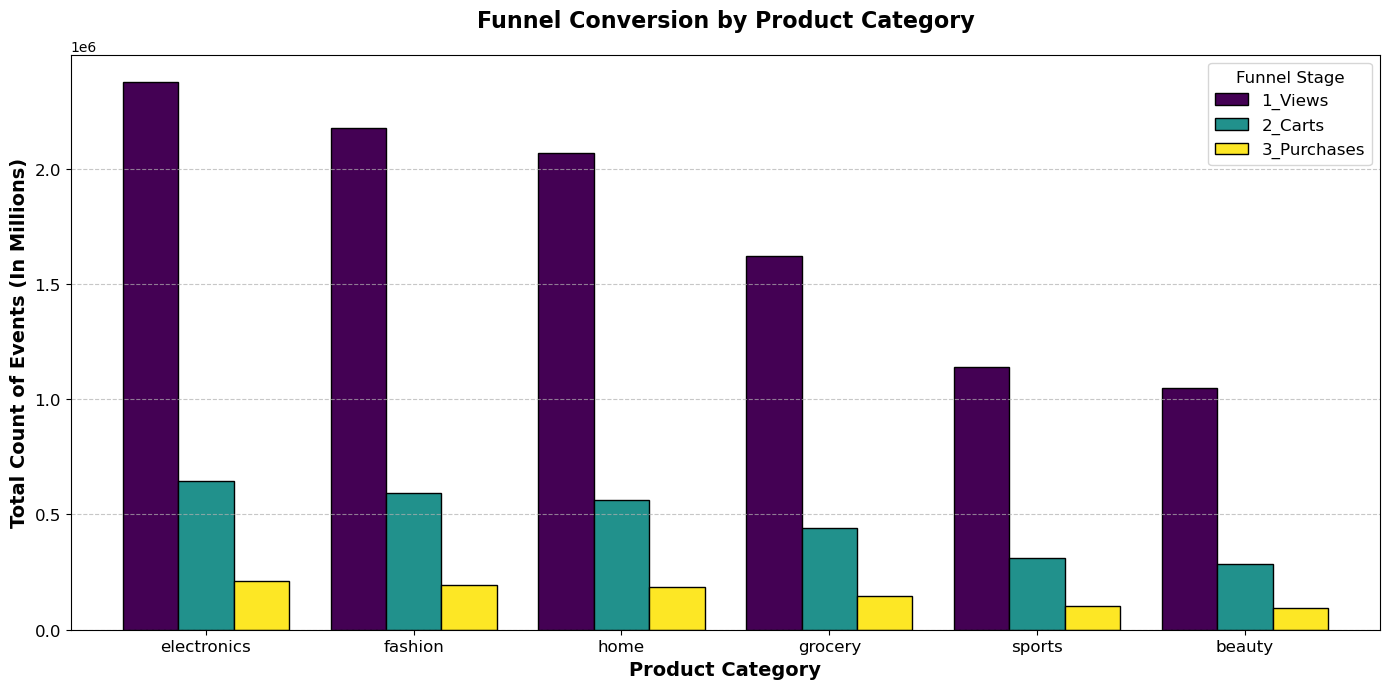

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum as _sum

# 1. Initialize local Spark session for Jupyter
spark = SparkSession.builder \
    .appName("Funnel_Visualization") \
    .master("local[*]") \
    .getOrCreate()

# 2. Read the funnel metrics Parquet file we generated in Stage 3
funnel_df = spark.read.parquet("/home/jovyan/work/output/funnel_metrics")

# 3. Aggregate the massive dataset down to just Category Totals
category_funnel = funnel_df.groupBy("category").agg(
    _sum("total_views").alias("1_Views"),
    _sum("total_carts").alias("2_Carts"),
    _sum("total_purchases").alias("3_Purchases")
).orderBy("1_Views", ascending=False) # Sort so the biggest categories are on the left

# 4. Pull the tiny, aggregated result out of Spark into a Pandas DataFrame
pdf = category_funnel.toPandas()

# 5. Set the category column as the index so Pandas knows to group the bars by it
pdf.set_index('category', inplace=True)

# 6. Draw the Grouped Bar Chart
ax = pdf.plot(kind='bar', figsize=(14, 7), colormap='viridis', width=0.8, edgecolor='black')

# 7. Make it look beautiful and professional
plt.title("Funnel Conversion by Product Category", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Product Category", fontsize=14, fontweight='bold')
plt.ylabel("Total Count of Events (In Millions)", fontsize=14, fontweight='bold')

# Rotate the category names so they don't overlap
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.yticks(fontsize=12)

# Add a grid for readability and clean up the legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Funnel Stage", fontsize=12, title_fontsize=12)

# Display the final chart
plt.tight_layout()
plt.show()

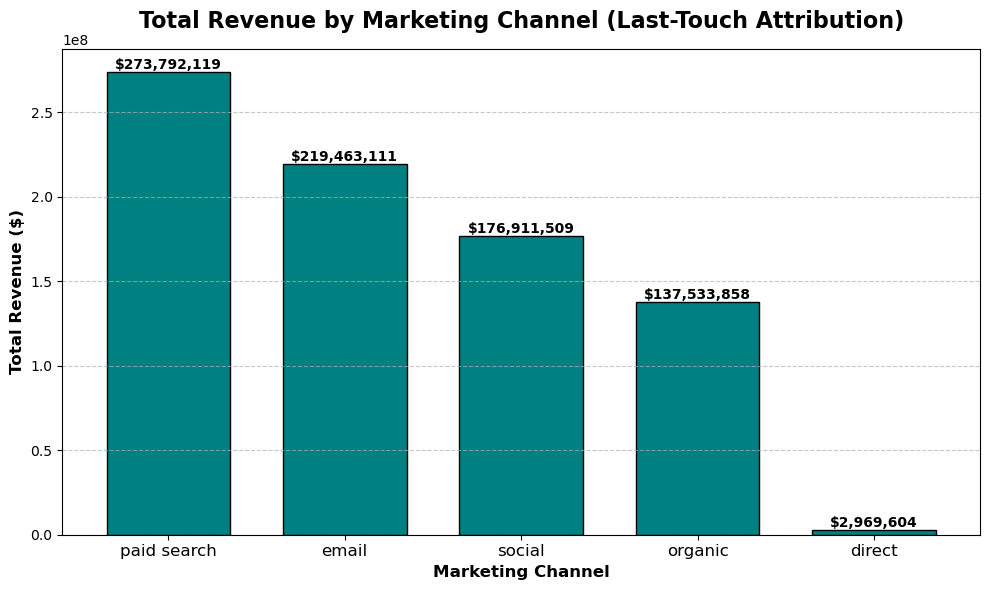

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum as _sum, col

# 1. Initialize local Spark session
spark = SparkSession.builder \
    .appName("View_Attribution") \
    .master("local[*]") \
    .getOrCreate()

# 2. Load the attributed orders Parquet file
attributed_df = spark.read.parquet("/home/jovyan/work/output/attributed_orders")

# ==========================================
# 3. AGGREGATE THE DATA (This is the missing step)
# ==========================================
# Group the data by channel, sum the revenue, and sort from highest to lowest
channel_metrics = attributed_df.groupBy("marketing_channel").agg(
    _sum("total_amount").alias("total_revenue")
).orderBy(col("total_revenue").desc())

# ==========================================
# 4. VISUALIZATION: Revenue Bar Chart
# ==========================================
# Pull the newly aggregated data into Pandas
pdf = channel_metrics.toPandas()
pdf.set_index("marketing_channel", inplace=True)

# Draw the chart
ax = pdf['total_revenue'].plot(kind='bar', figsize=(10, 6), color='teal', edgecolor='black', width=0.7)

# Format the chart to look professional
plt.title("Total Revenue by Marketing Channel (Last-Touch Attribution)", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Marketing Channel", fontsize=12, fontweight='bold')
plt.ylabel("Total Revenue ($)", fontsize=12, fontweight='bold')
plt.xticks(rotation=0, ha='center', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add exact dollar amounts on top of the bars
for p in ax.patches:
    ax.annotate(f"${p.get_height():,.0f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Generating timeline for category: BEAUTY...


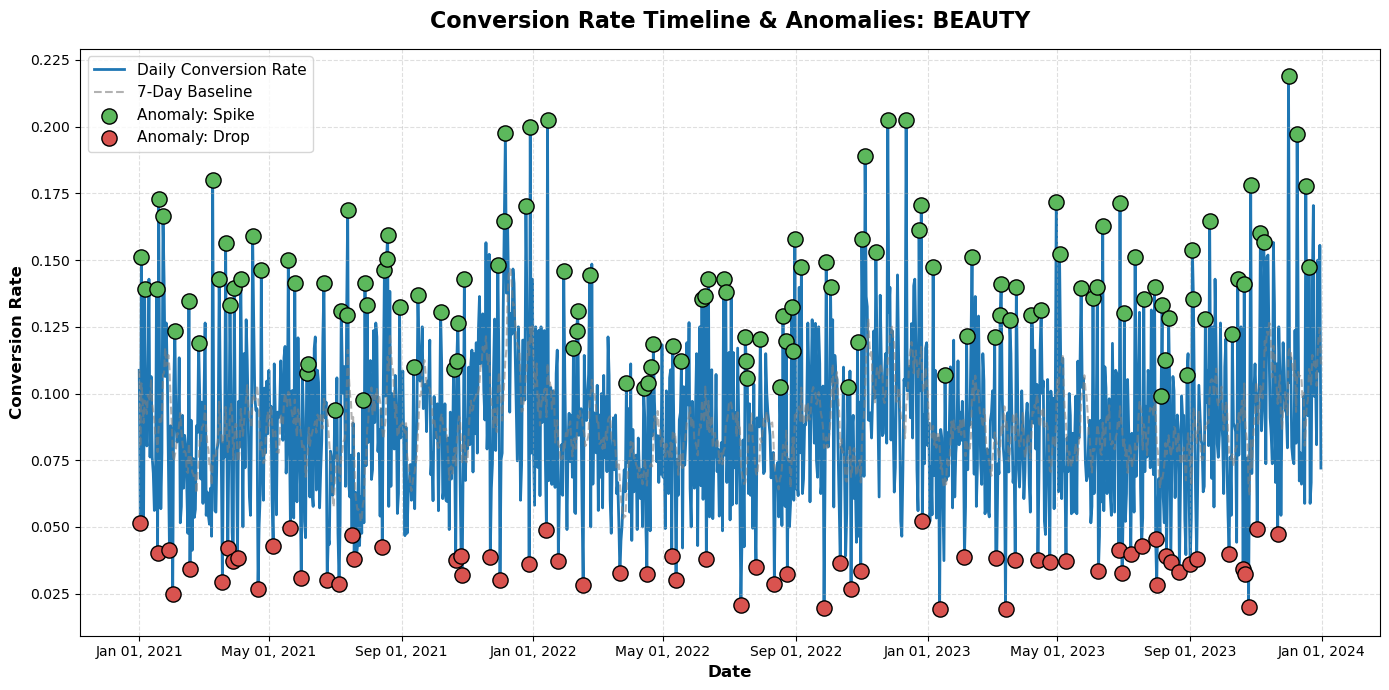

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum as _sum, col, when

# 1. Initialize local Spark session
spark = SparkSession.builder.appName("Visualize_Electronics_Anomalies").master("local[*]").getOrCreate()

# 2. Load BOTH the continuous funnel metrics and the isolated anomalies
# Use the Jupyter environment paths
funnel_df = spark.read.parquet("/home/jovyan/work/output/funnel_metrics")
anomalies_df = spark.read.parquet("/home/jovyan/work/output/anomalies")

# 3. Target specifically the electronics category
target_category = "beauty"

print(f"Generating timeline for category: {target_category.upper()}...")

# ==========================================
# 4. RECONSTRUCT THE TIMELINE
# ==========================================
# Filter funnel data for 'electronics' and calculate the daily conversion rate
timeline_df = funnel_df.filter(col("category") == target_category) \
    .groupBy("date").agg(
        _sum("total_views").alias("views"),
        _sum("total_purchases").alias("purchases")
    ).withColumn(
        "conversion_rate",
        when(col("views") > 0, col("purchases") / col("views")).otherwise(0.0)
    )

# Pull to Pandas and sort chronologically so the line draws left-to-right correctly
pdf_timeline = timeline_df.toPandas().sort_values("date")
pdf_timeline['date'] = pd.to_datetime(pdf_timeline['date'])

# Re-calculate the 7-day moving average strictly for the visualization background
pdf_timeline['7d_baseline'] = pdf_timeline['conversion_rate'].rolling(window=7, min_periods=1).mean()

# ==========================================
# 5. ISOLATE THE ANOMALIES
# ==========================================
# Filter the anomalies table specifically for 'electronics'
pdf_anomalies = anomalies_df.filter(col("category") == target_category).toPandas()

# Merge to get the exact Y-axis coordinates (the conversion rate) for the anomaly dots
if not pdf_anomalies.empty:
    pdf_anomalies['date'] = pd.to_datetime(pdf_anomalies['date'])
    spikes = pd.merge(pdf_anomalies[pdf_anomalies['anomaly_type'] == 'SPIKE'], pdf_timeline, on='date')
    drops = pd.merge(pdf_anomalies[pdf_anomalies['anomaly_type'] == 'DROP'], pdf_timeline, on='date')
else:
    spikes = pd.DataFrame()
    drops = pd.DataFrame()

# ==========================================
# 6. DRAW THE LINE CHART
# ==========================================
plt.figure(figsize=(14, 7))

# The actual daily conversion rate (Solid Blue Line)
plt.plot(pdf_timeline['date'], pdf_timeline['conversion_rate'], 
         label='Daily Conversion Rate', color='#1f77b4', linewidth=2, zorder=1)

# The 7-day rolling baseline (Dashed Gray Line)
plt.plot(pdf_timeline['date'], pdf_timeline['7d_baseline'], 
         label='7-Day Baseline', color='gray', linestyle='--', alpha=0.6, zorder=1)

# Highlight the Spikes (Green Dots) - Notice we use 'conversion_rate' with no '_y'
if not spikes.empty:
    plt.scatter(spikes['date'], spikes['conversion_rate'], 
                color='#5cb85c', s=120, label='Anomaly: Spike', zorder=5, edgecolor='black')

# Highlight the Drops (Red Dots) - Notice we use 'conversion_rate' with no '_y'
if not drops.empty:
    plt.scatter(drops['date'], drops['conversion_rate'], 
                color='#d9534f', s=120, label='Anomaly: Drop', zorder=5, edgecolor='black')

# Formatting
plt.title(f"Conversion Rate Timeline & Anomalies: {target_category.upper()}", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12, fontweight='bold')
plt.ylabel("Conversion Rate", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=11)

# Format X-axis for clean date rendering
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.show()

Generating timeline for BEAUTY from 2023-10-01 to 2023-12-31...


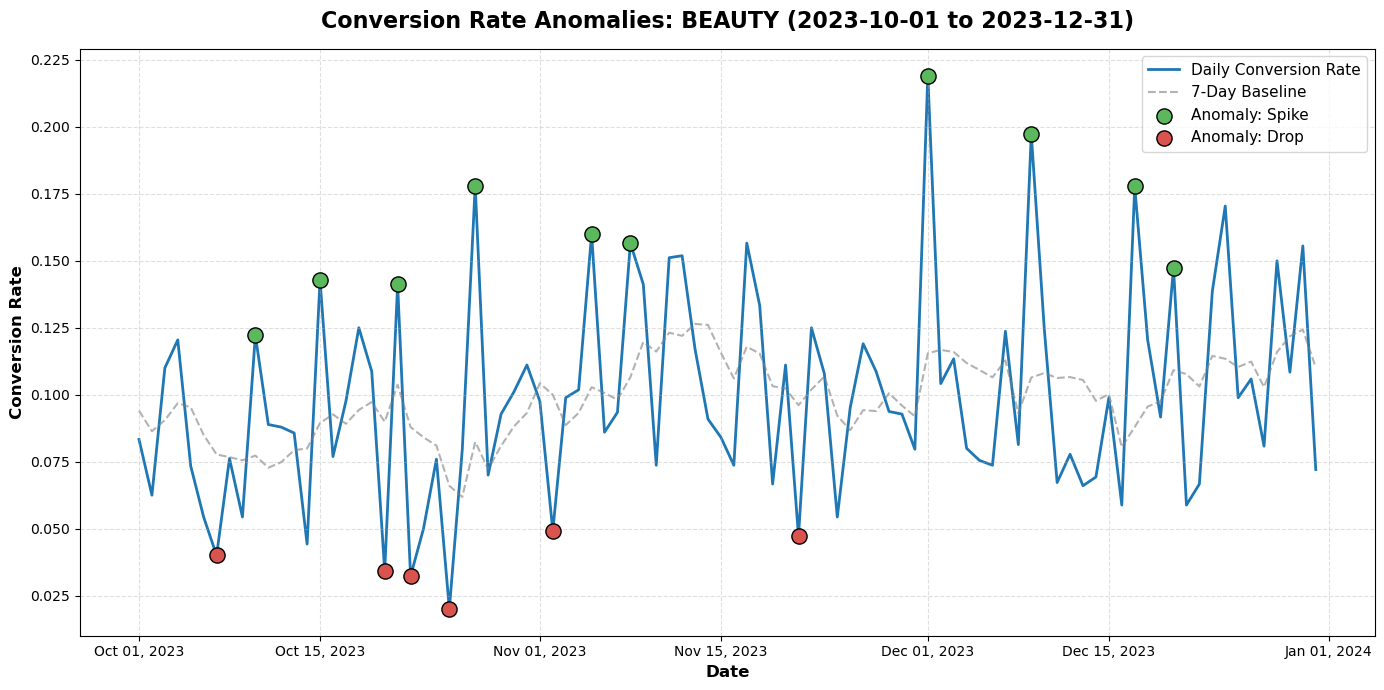

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pyspark.sql import SparkSession
from pyspark.sql.functions import sum as _sum, col, when

# 1. Initialize local Spark session
spark = SparkSession.builder.appName("Visualize_Electronics_DateRange").master("local[*]").getOrCreate()

# ==========================================
# 2. DEFINE FILTERS
# ==========================================
target_category = "beauty"
start_date = '2023-10-01' # <-- Change to your desired start date
end_date = '2023-12-31'   # <-- Change to your desired end date

print(f"Generating timeline for {target_category.upper()} from {start_date} to {end_date}...")

# 3. Load the data using Jupyter paths
funnel_df = spark.read.parquet("/home/jovyan/work/output/funnel_metrics")
anomalies_df = spark.read.parquet("/home/jovyan/work/output/anomalies")

# ==========================================
# 4. RECONSTRUCT THE TIMELINE 
# ==========================================
# Filter for electronics and calculate daily conversion rate across ALL dates
timeline_df = funnel_df.filter(col("category") == target_category) \
    .groupBy("date").agg(
        _sum("total_views").alias("views"),
        _sum("total_purchases").alias("purchases")
    ).withColumn(
        "conversion_rate",
        when(col("views") > 0, col("purchases") / col("views")).otherwise(0.0)
    )

# Pull to Pandas and sort chronologically
pdf_timeline = timeline_df.toPandas().sort_values("date")
pdf_timeline['date'] = pd.to_datetime(pdf_timeline['date'])

# Calculate the 7-day baseline on the FULL dataset so the math is accurate
pdf_timeline['7d_baseline'] = pdf_timeline['conversion_rate'].rolling(window=7, min_periods=1).mean()

# NOW slice the timeline strictly to the requested date range for the chart
mask = (pdf_timeline['date'] >= pd.to_datetime(start_date)) & (pdf_timeline['date'] <= pd.to_datetime(end_date))
pdf_filtered_timeline = pdf_timeline[mask].copy()

# ==========================================
# 5. ISOLATE THE ANOMALIES 
# ==========================================
# Filter anomalies for the category AND the date range
q_anomalies = anomalies_df.filter(
    (col("category") == target_category) & 
    (col("date").between(start_date, end_date))
)
pdf_anomalies = q_anomalies.toPandas()

# Merge to get the exact Y-axis coordinates for the dots
if not pdf_anomalies.empty:
    pdf_anomalies['date'] = pd.to_datetime(pdf_anomalies['date'])
    spikes = pd.merge(pdf_anomalies[pdf_anomalies['anomaly_type'] == 'SPIKE'], pdf_filtered_timeline, on='date')
    drops = pd.merge(pdf_anomalies[pdf_anomalies['anomaly_type'] == 'DROP'], pdf_filtered_timeline, on='date')
else:
    spikes = pd.DataFrame()
    drops = pd.DataFrame()

# ==========================================
# 6. DRAW THE LINE CHART
# ==========================================
plt.figure(figsize=(14, 7))

# Actual rate (Blue Line)
plt.plot(pdf_filtered_timeline['date'], pdf_filtered_timeline['conversion_rate'], 
         label='Daily Conversion Rate', color='#1f77b4', linewidth=2, zorder=1)

# Rolling baseline (Gray Line)
plt.plot(pdf_filtered_timeline['date'], pdf_filtered_timeline['7d_baseline'], 
         label='7-Day Baseline', color='gray', linestyle='--', alpha=0.6, zorder=1)

# Spikes (Green Dots)
if not spikes.empty:
    plt.scatter(spikes['date'], spikes['conversion_rate'], 
                color='#5cb85c', s=120, label='Anomaly: Spike', zorder=5, edgecolor='black')

# Drops (Red Dots)
if not drops.empty:
    plt.scatter(drops['date'], drops['conversion_rate'], 
                color='#d9534f', s=120, label='Anomaly: Drop', zorder=5, edgecolor='black')

# Formatting
plt.title(f"Conversion Rate Anomalies: {target_category.upper()} ({start_date} to {end_date})", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Date", fontsize=12, fontweight='bold')
plt.ylabel("Conversion Rate", fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=11)

# Clean X-Axis formatting
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d, %Y'))
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.show()

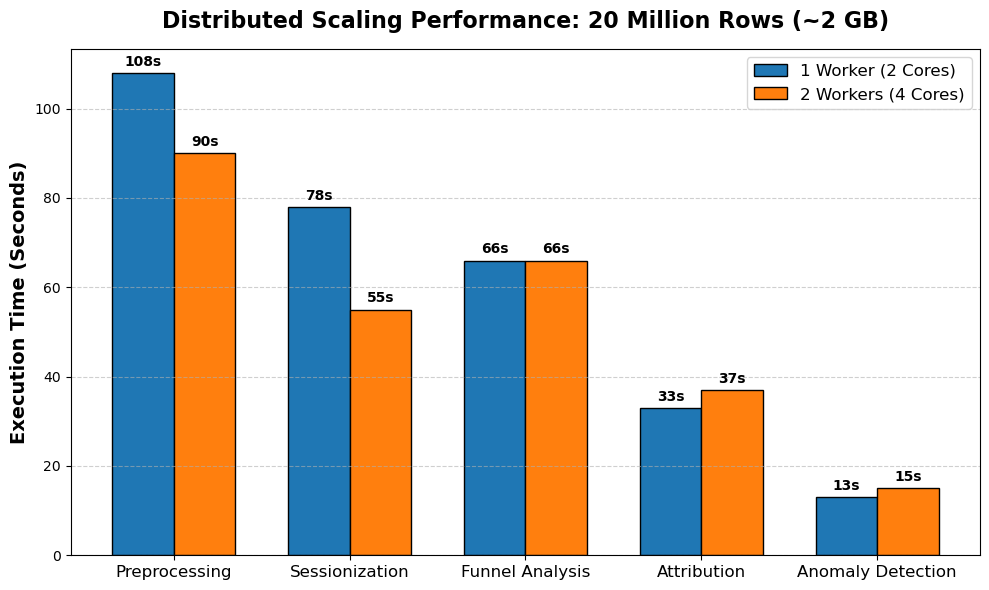

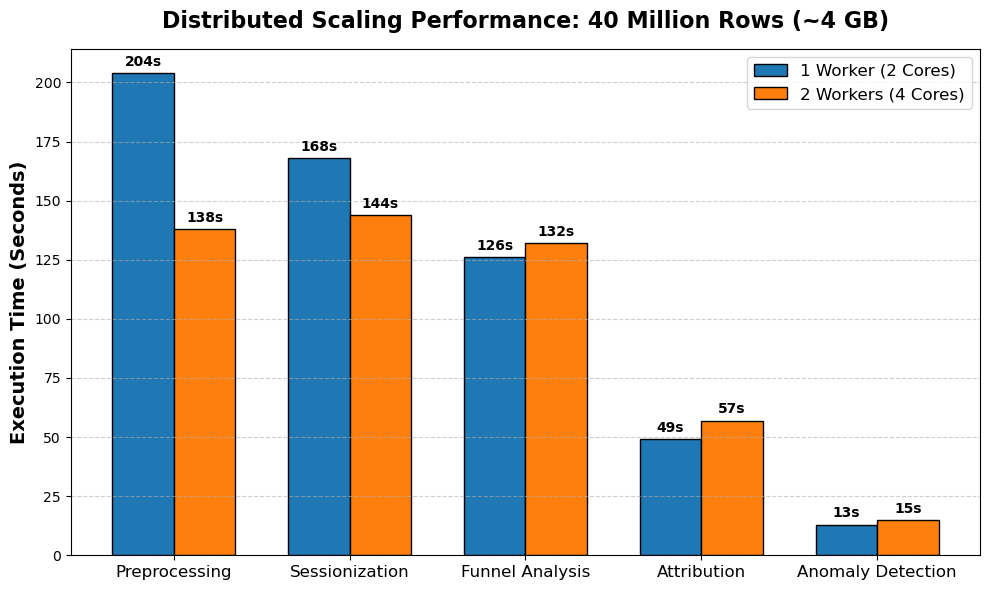

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Define pipeline stages in the exact execution order
stages = ['Preprocessing', 'Sessionization', 'Funnel Analysis', 'Attribution', 'Anomaly Detection']
x = np.arange(len(stages))  # the label locations
width = 0.35  # the width of the bars

# ==========================================
# EXACT DATA SETS (Converted to Seconds)
# ==========================================
# Data for 20 Million Rows
# 2 Cores = 1 Worker, 4 Cores = 2 Workers
time_1w_20m = [108, 78, 66, 33, 13]   # 1.8m, 1.3m, 1.1m, 33s, 13s
time_2w_20m = [90, 55, 66, 37, 15]    # 1.5m, 55s, 1.1m, 37s, 15s

# Data for 40 Million Rows
time_1w_40m = [204, 168, 126, 49, 13] # 3.4m, 2.8m, 2.1m, 49s, 13s
time_2w_40m = [138, 144, 132, 57, 15] # 2.3m, 2.4m, 2.2m, 57s, 15s

# Styling colors
color_1w = '#1f77b4' # Standard Matplotlib Blue
color_2w = '#ff7f0e' # Standard Matplotlib Orange

# Helper function to attach a text label above each bar
def autolabel(rects, ax):
    """Attach a text label above each bar in *rects*, displaying its height in seconds."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}s',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

# ==========================================
# PLOT 1: 20 MILLION ROWS
# ==========================================
fig1, ax1 = plt.subplots(figsize=(10, 6))

rects1_20 = ax1.bar(x - width/2, time_1w_20m, width, label='1 Worker (2 Cores)', color=color_1w, edgecolor='black')
rects2_20 = ax1.bar(x + width/2, time_2w_20m, width, label='2 Workers (4 Cores)', color=color_2w, edgecolor='black')

ax1.set_title('Distributed Scaling Performance: 20 Million Rows (~2 GB)', fontsize=16, fontweight='bold', pad=15)
ax1.set_ylabel('Execution Time (Seconds)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(stages, fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.6)
ax1.legend(fontsize=12, loc='upper right')

autolabel(rects1_20, ax1)
autolabel(rects2_20, ax1)

plt.tight_layout()
plt.show()

# ==========================================
# PLOT 2: 40 MILLION ROWS
# ==========================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

rects1_40 = ax2.bar(x - width/2, time_1w_40m, width, label='1 Worker (2 Cores)', color=color_1w, edgecolor='black')
rects2_40 = ax2.bar(x + width/2, time_2w_40m, width, label='2 Workers (4 Cores)', color=color_2w, edgecolor='black')

ax2.set_title('Distributed Scaling Performance: 40 Million Rows (~4 GB)', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Execution Time (Seconds)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(stages, fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.6)
ax2.legend(fontsize=12, loc='upper right')

autolabel(rects1_40, ax2)
autolabel(rects2_40, ax2)

plt.tight_layout()
plt.show()